# 13 · Design patterns without a framework

## Learning objectives

- Build fresh reusable subtrees.
- Combine monitoring, priorities, and tasks.
- Choose boundaries that match intent.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

A hierarchy is useful when its names summarize decisions. “Deliver object” can hide the
details of reaching, detecting, and grasping. A subtree factory is just a function returning
new nodes. A behavior instance has one parent and mutable execution state: never share one
instance between two parents. Share construction logic instead.

In [2]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display

## Minimal working example

1 Monitored task: RUNNING | Healthy?: SUCCESS | Survey: RUNNING | Left: RUNNING | Aim sensor: INVALID | Read sensor: INVALID | Right: INVALID
2 Monitored task: RUNNING | Healthy?: SUCCESS | Survey: RUNNING | Left: SUCCESS | Aim sensor: RUNNING | Read sensor: INVALID | Right: RUNNING
3 Monitored task: SUCCESS | Healthy?: SUCCESS | Survey: SUCCESS | Left: SUCCESS | Aim sensor: SUCCESS | Read sensor: SUCCESS | Right: SUCCESS


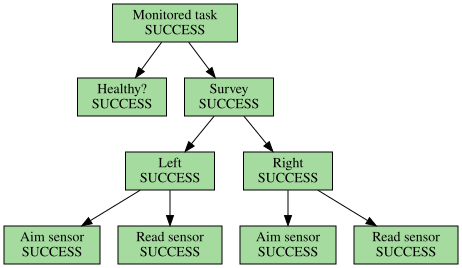

In [3]:
def inspect(name):
    return pt.composites.Sequence(name, memory=True, children=[
        CountTicks("Aim sensor", ticks=2), pt.behaviours.Success("Read sensor")])

healthy = {"value": True}

def factory():
    task = pt.composites.Sequence("Survey", memory=True, children=[inspect("Left"), inspect("Right")])
    return pt.composites.Sequence("Monitored task", memory=False, children=[
        Function("Healthy?", lambda: Status.SUCCESS if healthy["value"] else Status.FAILURE), task])

root = factory()
trace(root, 3)
assert root.status is Status.SUCCESS
display(diagram(root))

## Step-by-step implementation
The outer sequence is reactive so the monitor runs every tick. The inner sequence remembers
progress so a completed inspection is not restarted while the next one runs. This small
combination is often enough. A Parallel with a permanently RUNNING monitor and SuccessOnAll
would never finish; its success policy must match the intended task.

In [4]:
left, right = inspect("First"), inspect("Second")
assert left is not right and left.children[0] is not right.children[0]
healthy["value"] = False
root.tick_once()
assert root.status is Status.FAILURE
assert root.children[1].status is Status.INVALID
healthy["value"] = True

## Interactive demonstration

In [5]:
display(playground(factory))

## Key observations

Use names to expose intent and factories to reuse structure. Memory inside a task and reactivity around a monitor serve different purposes.

## Exercises

1. Put a low-battery priority branch around the monitored task.
2. Sketch a parallel success policy for monitoring until a task finishes.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 13).

## Summary

We have enough vocabulary to build a small robot without adding a robotics middleware yet.